# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [55]:
#%pip install icrawler
%pip install pyimagedl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\neope\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [56]:
import os
import shutil
import random
# stopped working - from icrawler.builtin import GoogleImageCrawler, BingImageCrawler
from imagedl import imagedl
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torchvision import models
import time
import copy
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
from PIL import Image


### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [57]:
def download_images(keyword, label, n_total=100, folder="data/kirby", image_source='GoogleImageClient'):
    final_folder = os.path.join(folder, label)
    os.makedirs(final_folder, exist_ok=True)
    
    # -- verificar se já tem imagens suficientes ---
    
    count_existing = len([f for f in os.listdir(final_folder) if f.lower().endswith(('.jpg', '.png'))])
    if count_existing >= n_total:
        print(f"[{label}] já possui {count_existing} imagens. Pulando...")
        return
    
    needed = n_total - count_existing
    print(f"⬇️ [{label}] Tem {count_existing}. Baixando mais {needed}...")

    # --- lógicas de pasta --
    temp_folder = final_folder + "_temp"
    if os.path.exists(temp_folder): shutil.rmtree(temp_folder)

    try:
        client = imagedl.ImageClient(
            image_source=image_source, 
            init_image_client_cfg={'work_dir': temp_folder},
            search_limits=needed + 20,
            num_threadings=4
        )
        
        image_infos = client.search(keyword, search_limits_overrides=needed + 20)
        client.download(image_infos=image_infos)
        
        # mvoer e renomear
        new_count = count_existing
        moved = 0
        
        for root, dirs, files in os.walk(temp_folder):
            for file in files:
                if moved >= needed: break # Para se já completou
                
                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    src = os.path.join(root, file)
                    # Gera nome único para não sobrescrever as antigas (ex: meta_knight_101.jpg)
                    dst = os.path.join(final_folder, f"{label}_{new_count:04d}.jpg")
                    
                    try:
                        shutil.move(src, dst)
                        new_count += 1
                        moved += 1
                    except Exception as e:
                        pass 
                        
        print(f"   Concluído! Total atual de {label}: {new_count}")

    except Exception as e:
        print(f"Erro ao baixar {label}: {e}")
    finally:
        if os.path.exists(temp_folder):
            shutil.rmtree(temp_folder)

In [58]:
dataset_root = 'data/kirby'

search_terms = {
    "kirby": 'kirby character -waddle -meta -king -bandana -dedede -dee -doo',
    "dee": 'waddle dee character -bandana',
    "bandana_dee": 'bandana waddle dee character',
    "king": 'king dedede character',
    "meta_knight": 'meta knight kirby character',
    "waddle_doo": 'waddle doo kirby character -dee' 
}


if not os.path.exists(dataset_root) or len(os.listdir(dataset_root)) == 0:
    print("downloading")
    for label, term in search_terms.items():
        download_images(term, label, n_total=100, folder=dataset_root)


Após esse passo, as imagens de cada classe foram curadas manualmente para manter somente as relevantes.

### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [59]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [60]:
# transform e normalizacao
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])



In [61]:
#dataset
train_dir = 'data/kirby_split/train'
val_dir = 'data/kirby_split/val'
split_train_val(dataset_root)

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True)

class_names = train_dataset.classes
print(class_names)
print(f"Total treino: {len(train_dataset)}")
print(f"Total validação: {len(val_dataset)}")

bandana_dee: 47 train, 12 val
dee: 32 train, 8 val
king: 40 train, 11 val
kirby: 32 train, 8 val
meta_knight: 34 train, 9 val
waddle_doo: 40 train, 10 val
['bandana_dee', 'dee', 'king', 'kirby', 'meta_knight', 'waddle_doo']
Total treino: 225
Total validação: 58


## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [62]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

def get_model(model_name, num_classes, feature_extract=True):
    """
    Inicializa um modelo pré-treinado e redefine a última camada.
    model_name: 'resnet18', 'mobilenet_v2', 'efficientnet_b0'
    """
    model = None

    # Resnet18 com/sem dropout
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False # Congeelando pesos
        
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == "resnet18_dropout":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False 
        
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_ftrs, num_classes)
        )

    # MobileNetV2 com/sem dropout
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False
        
        # camada final 
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)
        
    elif model_name == "mobilenet_v2_dropout":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False
        
        # dropout 0.5
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(model.last_channel, num_classes)
        )
    
    # EfficientNetB0 com/sem dropout
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False
        
        # última camada
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    elif model_name == "efficientnet_b0_dropout":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False
            
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_ftrs, num_classes)
        )

    else:
        print("Erro no nome do modelo; retornando resnet18")
        return get_model("resnet18", num_classes, feature_extract)

    return model.to(device)

Usando dispositivo: cuda


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [63]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=10):
    since = time.time()
    
    val_acc_history = []
    train_acc_history = []
    train_loss_history = []
    val_loss_history = []
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # treinamento e validação
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # iteração
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy do modelo se for o melhor até agora
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            
            # histórico pra métricas
            if phase == 'val':
                val_acc_history.append(epoch_acc.item())
                val_loss_history.append(epoch_loss)
            else:
                train_acc_history.append(epoch_acc.item())
                train_loss_history.append(epoch_loss)

    time_elapsed = time.time() - since
    print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia de Validação: {best_acc:.4f}')

    # Carrega os melhores pesos
    model.load_state_dict(best_model_wts)
    
    history = {
        'train_loss': train_loss_history, 'val_loss': val_loss_history,
        'train_acc': train_acc_history, 'val_acc': val_acc_history
    }
    return model, history

In [64]:
# --- TREINAMENTO ---

# Arquiteturas para testar
model_names = ['resnet18', 'resnet18_dropout', 'mobilenet_v2', 'mobilenet_v2_dropout', 'efficientnet_b0', 'efficientnet_b0_dropout']
results = {}
dataloaders_dict = {'train': train_loader, 'val': val_loader}
num_classes = len(class_names)

criterion = nn.CrossEntropyLoss()

best_overall_acc = 0
best_model_name = ""
final_model = None
final_history = None

for name in model_names:
    print(f"\nTraining Model: {name}")
    model_ft = get_model(name, num_classes, feature_extract=True)
    
    #otimizar apenas camadas não congeladas
    params_to_update = [p for p in model_ft.parameters() if p.requires_grad]
    optimizer_ft = optim.Adam(params_to_update, lr=0.001)
    
    # Trreinamento
    model_ft, hist = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft, num_epochs=10)
    results[name] = hist
    
    # selecionando um modelo para inferência
    if max(hist['val_acc']) > best_overall_acc:
        best_overall_acc = max(hist['val_acc'])
        best_model_name = name
        final_model = model_ft
        final_history = hist

print(f"\nSelecionado modelo como melhor: {best_model_name} com {best_overall_acc:.4f} acc")


Training Model: resnet18
Epoch 1/10
----------
train Loss: 1.8217 Acc: 0.2356
val Loss: 1.5445 Acc: 0.3966
Epoch 2/10
----------
train Loss: 1.4647 Acc: 0.4356
val Loss: 1.3226 Acc: 0.4483
Epoch 3/10
----------
train Loss: 1.1945 Acc: 0.6578
val Loss: 1.0461 Acc: 0.6207
Epoch 4/10
----------
train Loss: 1.0111 Acc: 0.7200
val Loss: 0.9406 Acc: 0.7414
Epoch 5/10
----------
train Loss: 0.8726 Acc: 0.7956
val Loss: 0.8623 Acc: 0.7586
Epoch 6/10
----------
train Loss: 0.8057 Acc: 0.7956
val Loss: 0.7959 Acc: 0.7586
Epoch 7/10
----------
train Loss: 0.7037 Acc: 0.8222
val Loss: 0.7123 Acc: 0.7759
Epoch 8/10
----------
train Loss: 0.6930 Acc: 0.8533
val Loss: 0.7435 Acc: 0.7759
Epoch 9/10
----------
train Loss: 0.6983 Acc: 0.8222
val Loss: 0.6715 Acc: 0.8103
Epoch 10/10
----------
train Loss: 0.6318 Acc: 0.8489
val Loss: 0.6717 Acc: 0.7414
Treinamento completo em 1m 32s
Melhor Acurácia de Validação: 0.8103

Training Model: resnet18_dropout
Epoch 1/10
----------
train Loss: 2.0132 Acc: 0.195

In [65]:
print("\n" + "="*40)
print("ACURÁCIAS DE VALIDAÇÃO POR MODELO")
print("="*40)

summary_data = []
for model_name, history in results.items():
    # Pega o maior valor que a acurácia atingiu durante o treino
    best_acc = max(history['val_acc'])
    summary_data.append([model_name, best_acc])

# Tabela de validações
df_results = pd.DataFrame(summary_data, columns=['Modelo', 'Acurácia Validação'])
df_results = df_results.sort_values(by='Acurácia Validação', ascending=False).reset_index(drop=True)

print(df_results)


ACURÁCIAS DE VALIDAÇÃO POR MODELO
                    Modelo  Acurácia Validação
0  efficientnet_b0_dropout            0.879310
1          efficientnet_b0            0.827586
2     mobilenet_v2_dropout            0.810345
3                 resnet18            0.810345
4             mobilenet_v2            0.758621
5         resnet18_dropout            0.741379


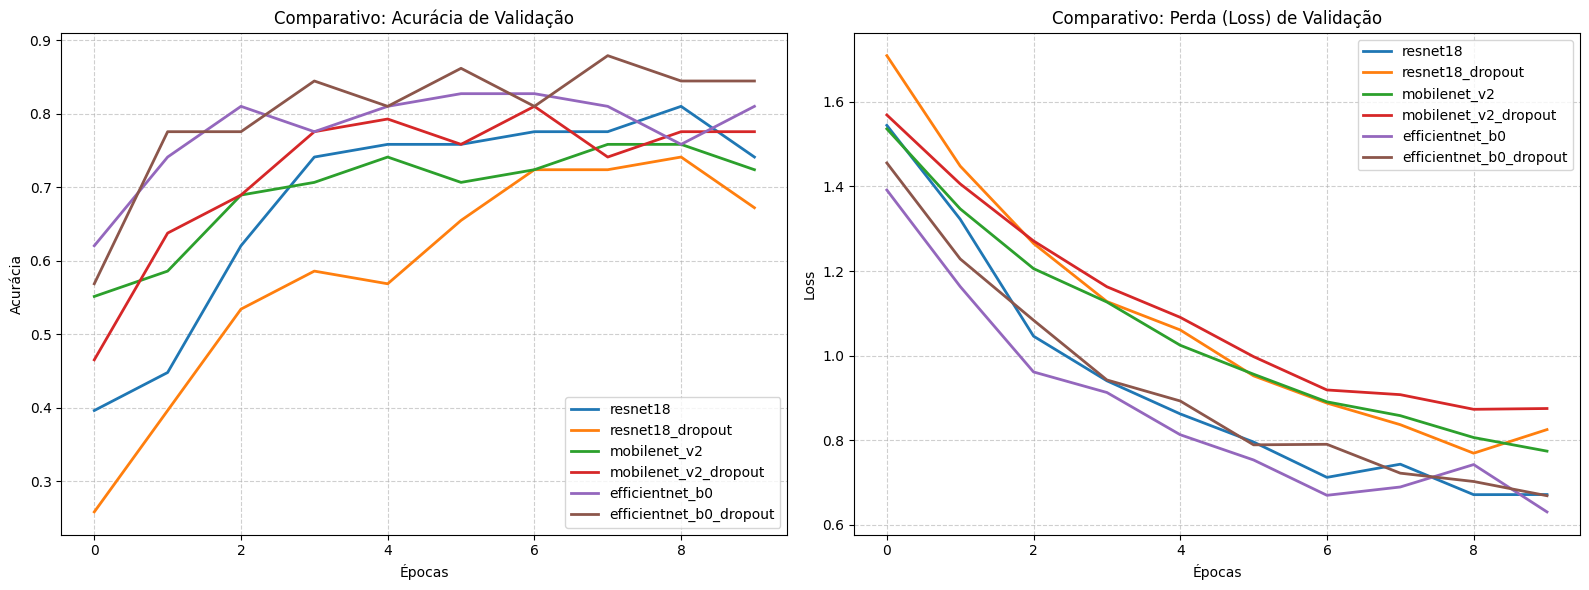

In [66]:
# --- Comparando arquiteturas --
plt.figure(figsize=(16, 6))

# Gráfico 1: Comparação de Acurácia (Validação)
plt.subplot(1, 2, 1)
for model_name, history in results.items():
    plt.plot(history['val_acc'], label=f'{model_name}', linewidth=2)

plt.title('Comparativo: Acurácia de Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Comparação de Loss (Validação)
plt.subplot(1, 2, 2)
for model_name, history in results.items():
    plt.plot(history['val_loss'], label=f'{model_name}', linewidth=2)

plt.title('Comparativo: Perda (Loss) de Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


--- Perdas Individuais ---


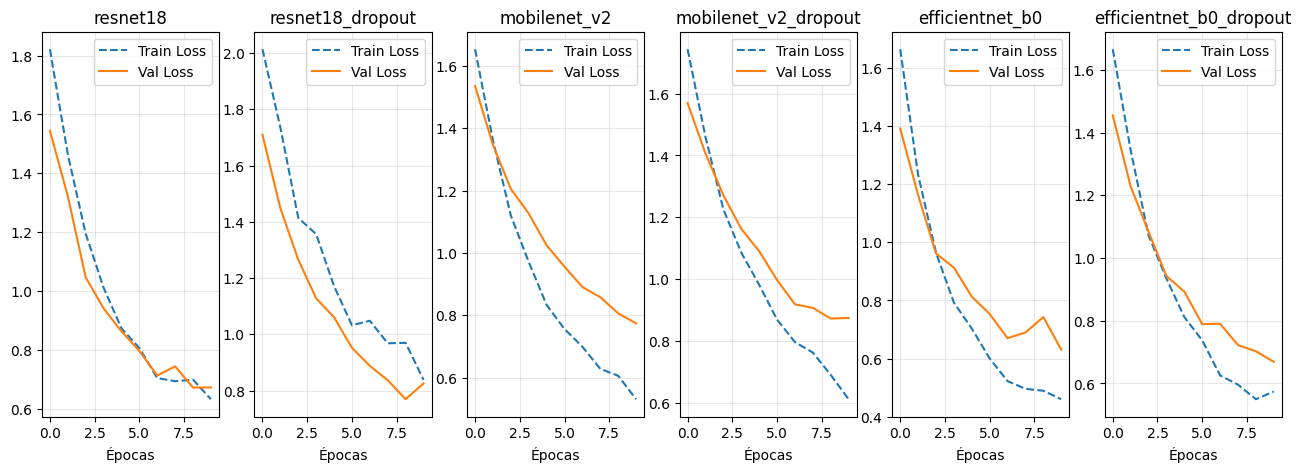

In [67]:
# --- Plotagem Individual de Treino x Validação ---
print("\n--- Perdas Individuais ---")
fig, axes = plt.subplots(1, len(model_names), figsize=(16, 5))

if len(model_names) == 1: axes = [axes]

for idx, model_name in enumerate(model_names):
    history = results[model_name]
    ax = axes[idx]
    ax.plot(history['train_loss'], label='Train Loss', linestyle='--')
    ax.plot(history['val_loss'], label='Val Loss')
    ax.set_title(f"{model_name}")
    ax.set_xlabel('Épocas')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.show()

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

### Métricas para conjunto de Validação

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def imshow(inp, title=None):
    """Função para desnormalizar e exibir a imagem"""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

Relatório de Classificação:
              precision    recall  f1-score   support

 bandana_dee       0.80      0.67      0.73        12
         dee       0.88      0.88      0.88         8
        king       0.85      1.00      0.92        11
       kirby       1.00      1.00      1.00         8
 meta_knight       0.90      1.00      0.95         9
  waddle_doo       0.89      0.80      0.84        10

    accuracy                           0.88        58
   macro avg       0.89      0.89      0.88        58
weighted avg       0.88      0.88      0.88        58



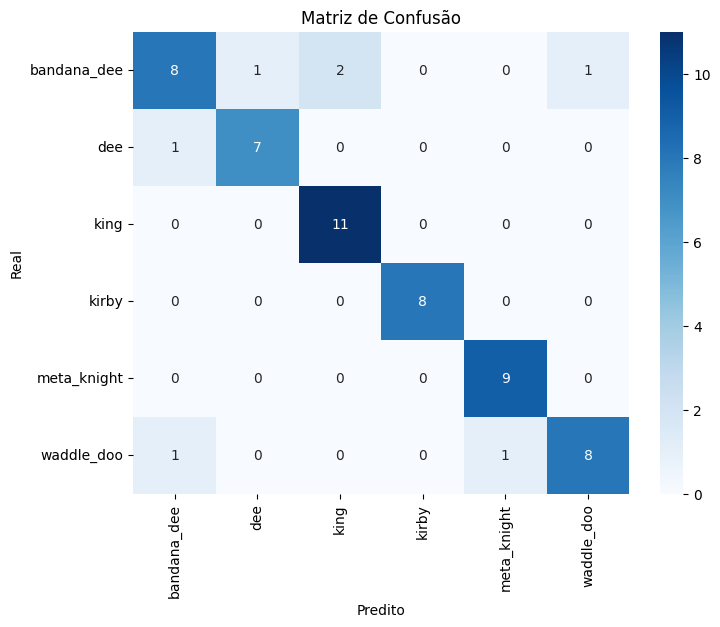

In [69]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

# gerando métricas
y_true, y_pred = evaluate_model(final_model, val_loader)

print("Relatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_names))

# confsuion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

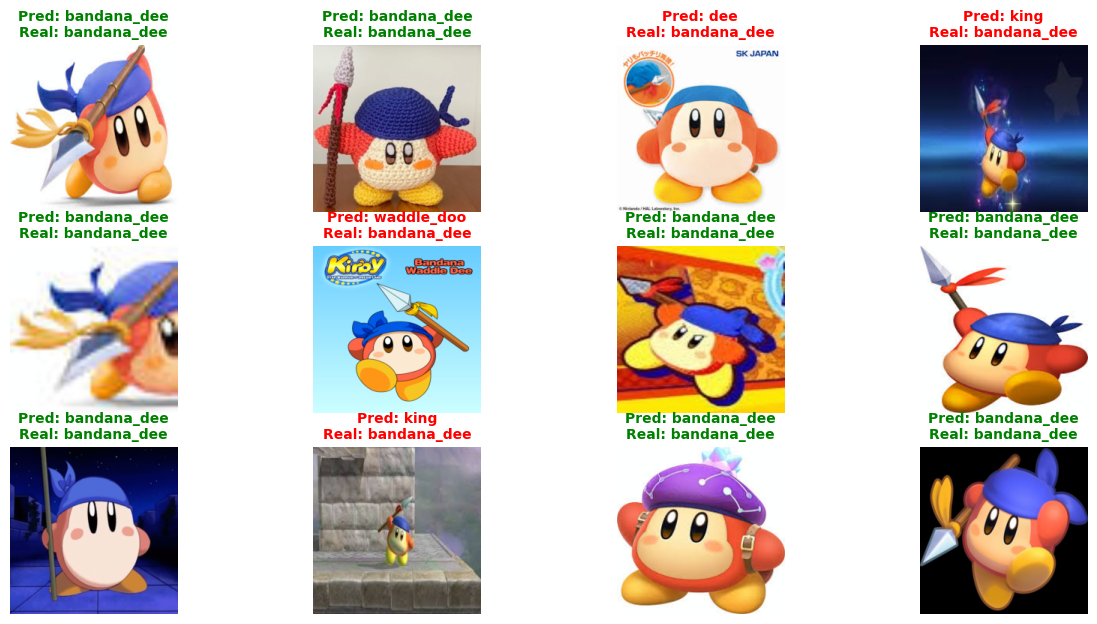

In [119]:
def visualize_model_predictions(model, dataloaders, num_images=12, seed=42):
    if seed is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        np.random.seed(seed)
    
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images//4 + 1, 4, images_so_far)
                
                # Define cor: Verde se acertou, Vermelho se errou
                color = 'green' if preds[j] == labels[j] else 'red'
                
                title = f'Pred: {class_names[preds[j]]}\nReal: {class_names[labels[j]]}'
                
                # Plota imagem
                imshow(inputs.data[j])
                ax.set_title(title, color=color, fontsize=10, fontweight='bold')

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# visualize
visualize_model_predictions(final_model, dataloaders_dict)

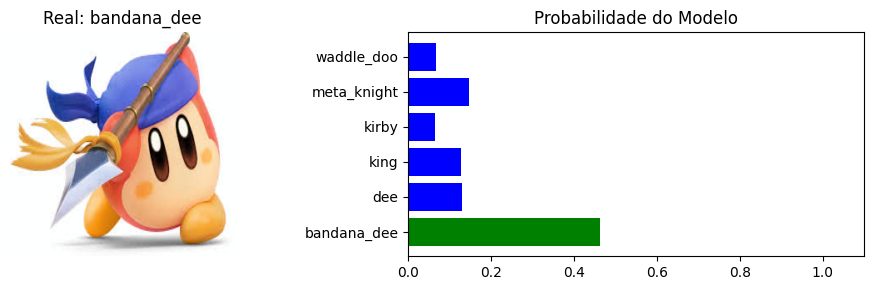

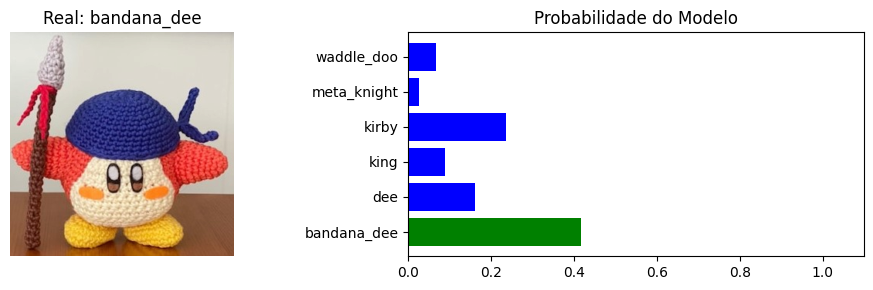

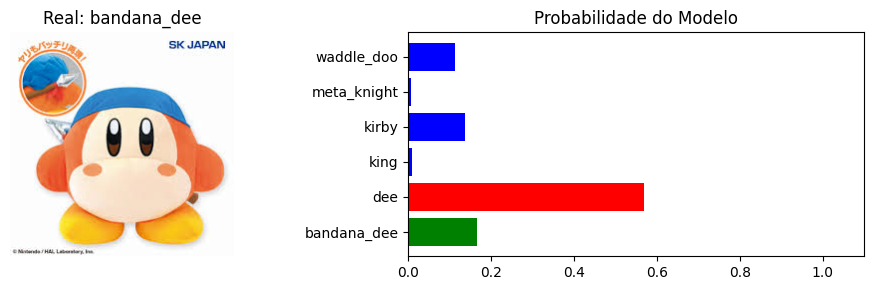

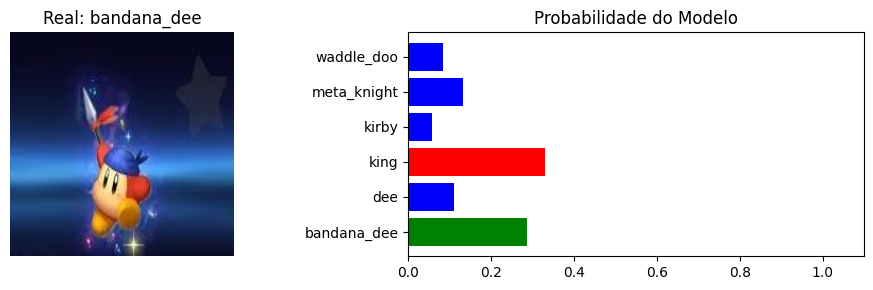

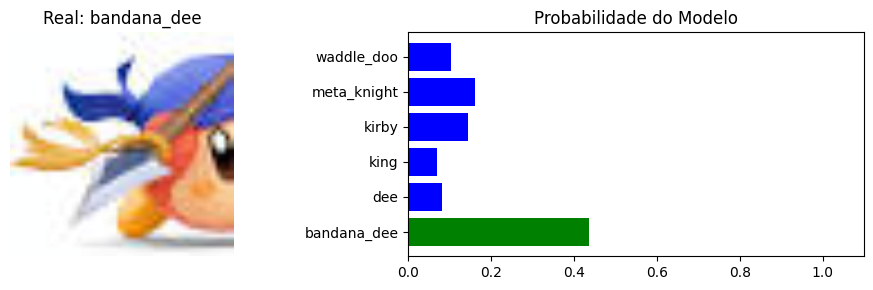

In [125]:
import torch.nn.functional as F


def visualize_uncertainty(model, dataloaders, num_images=5, seed=42):
    if seed is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        np.random.seed(seed)

    model.eval()

    images_so_far = 0

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # probabilities
    with torch.no_grad():
        for inputs, labels in dataloaders["val"]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)

            # plotting
            for j in range(inputs.size(0)):
                if images_so_far >= num_images:
                    return

                images_so_far += 1

                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

                # image
                img = inputs[j].cpu().numpy().transpose((1, 2, 0))
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax1.imshow(img)
                ax1.axis("off")
                ax1.set_title(f"Real: {class_names[labels[j]]}")

                # bar charrt
                p = probs[j].cpu().numpy()
                predicted_idx = np.argmax(p)

                colors = ["blue"] * len(class_names)

                if predicted_idx == labels[j]:
                    colors[predicted_idx] = "green"
                else:
                    colors[predicted_idx] = "red"
                    colors[labels[j]] = "green"

                ax2.barh(class_names, p, color=colors)
                ax2.set_xlim(0, 1.1)
                ax2.set_title("Probabilidade do Modelo")

                plt.tight_layout()
                plt.show()

# visualize
visualize_uncertainty(final_model, dataloaders_dict)

In [72]:
# fnução pra avaliar acur´cia
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return correct / total

In [73]:

# Set de treino baixado manualmente
external_root = 'data/kirby_challenge'

external_dataset = datasets.ImageFolder(root=external_root, transform=val_transform)
external_loader = DataLoader(external_dataset, batch_size=4, shuffle=True)

print(f"\nImagens de teste externo carregadas: {len(external_dataset)}")
print(f"Classes encontradas: {external_dataset.classes}")

# avaliar o melhor modelo nos dados
print(f"\n--- Avaliando o modelo ({best_model_name}) no conjunto de Teste ---")


acc_external = evaluate_accuracy(final_model, external_loader)
print(f"Acurácia no conjunto de teste: {acc_external*100:.2f}%")


Imagens de teste externo carregadas: 41
Classes encontradas: ['bandana_dee', 'dee', 'king', 'kirby', 'meta_knight', 'waddle_doo']

--- Avaliando o modelo (efficientnet_b0_dropout) no conjunto de Teste ---
Acurácia no conjunto de teste: 70.73%


In [74]:
test_dict = {'val': external_loader}
y_true_ext, y_pred_ext = evaluate_model(final_model, external_loader)
print(classification_report(y_true_ext, y_pred_ext, target_names=class_names))


              precision    recall  f1-score   support

 bandana_dee       0.67      0.25      0.36         8
         dee       0.67      0.67      0.67         6
        king       1.00      0.83      0.91         6
       kirby       0.50      0.78      0.61         9
 meta_knight       0.71      0.83      0.77         6
  waddle_doo       1.00      1.00      1.00         6

    accuracy                           0.71        41
   macro avg       0.76      0.73      0.72        41
weighted avg       0.73      0.71      0.69        41



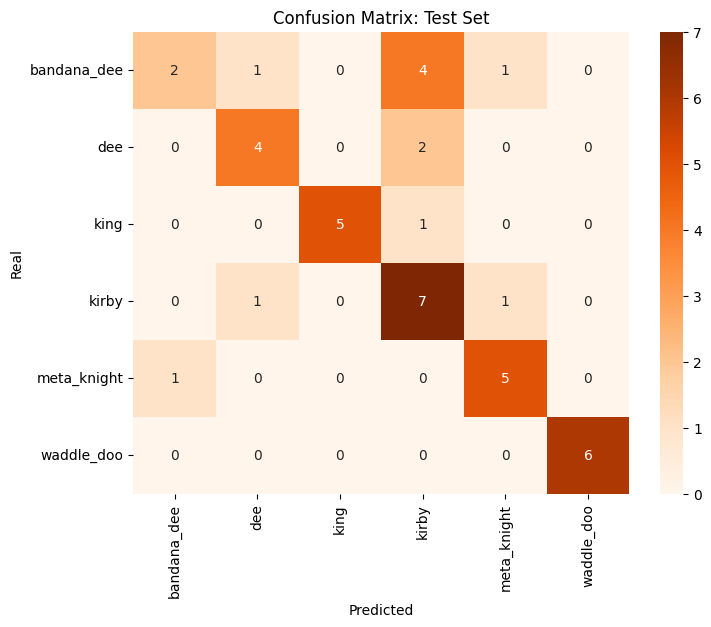


 -- GALERIA DE ACERTOS E ERROS -- 


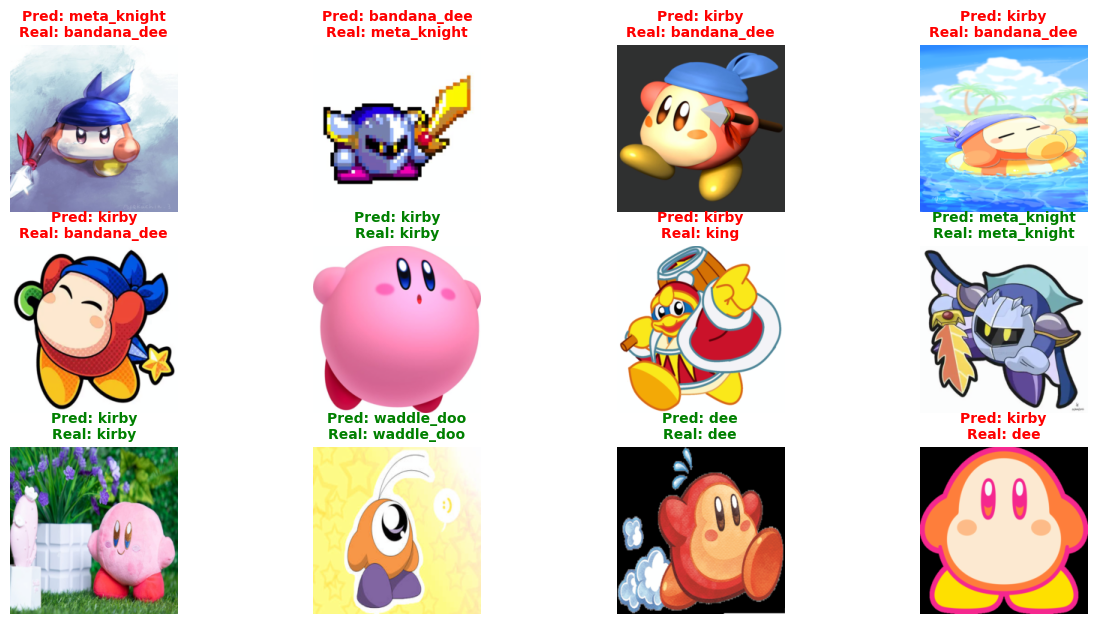

In [121]:
# Confusion Matrix
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ext, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix: Test Set')
plt.show()

# --- GALERIA DE PREDIÇÕES ---
print("\n -- GALERIA DE ACERTOS E ERROS -- ")
# Aqui também usamos o dicionário test_dict
visualize_model_predictions(final_model, test_dict, num_images=12)


 -- VISUALIZAÇÃO DE INCERTEZA -- 


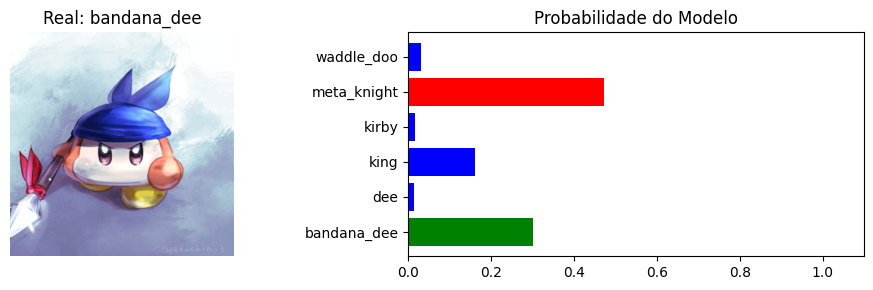

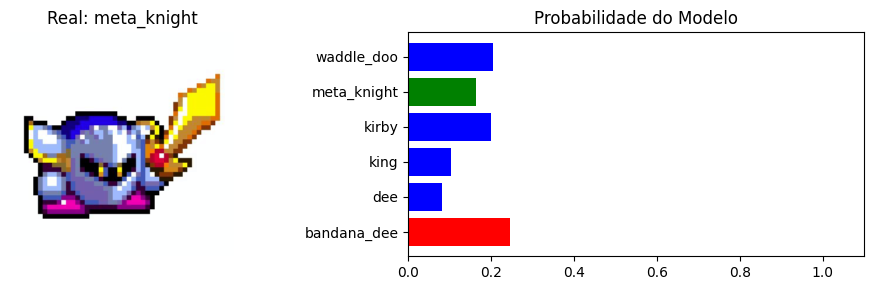

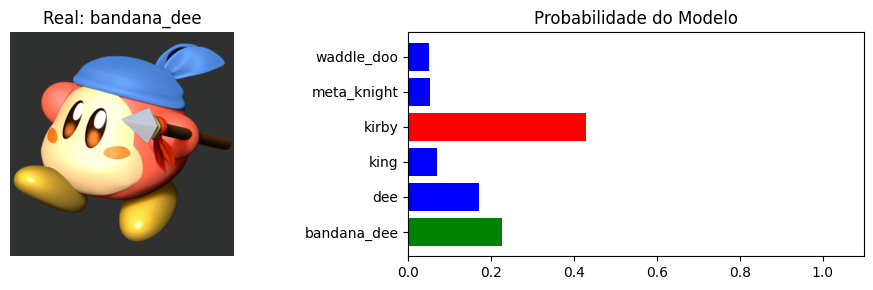

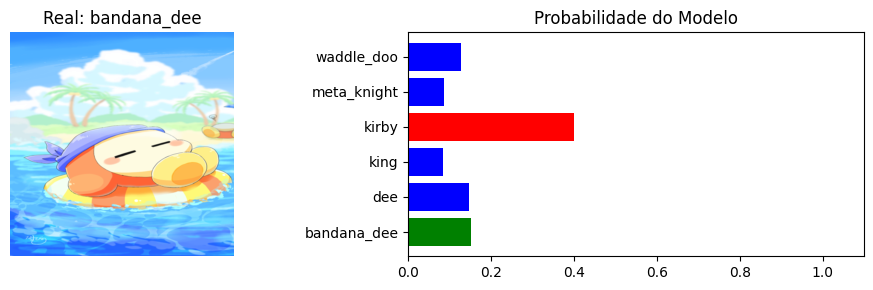

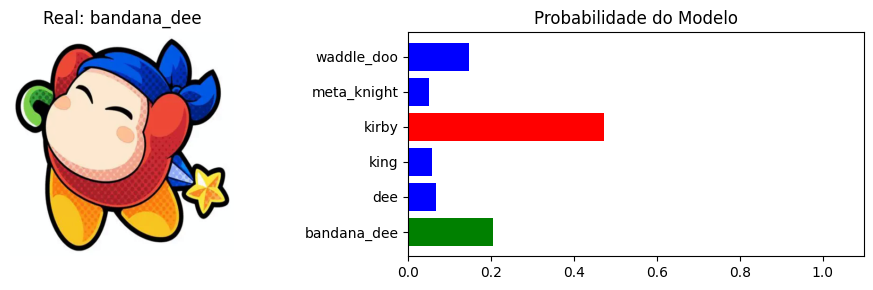

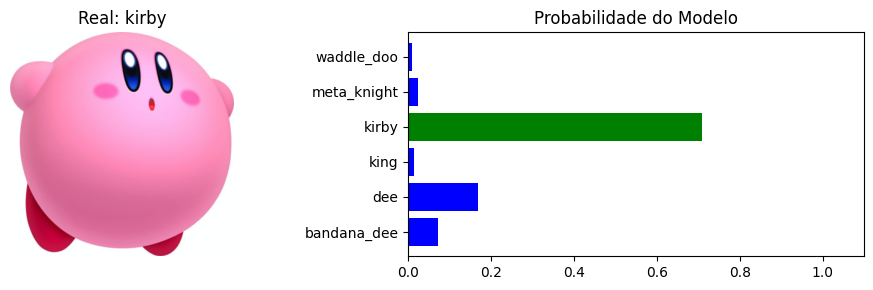

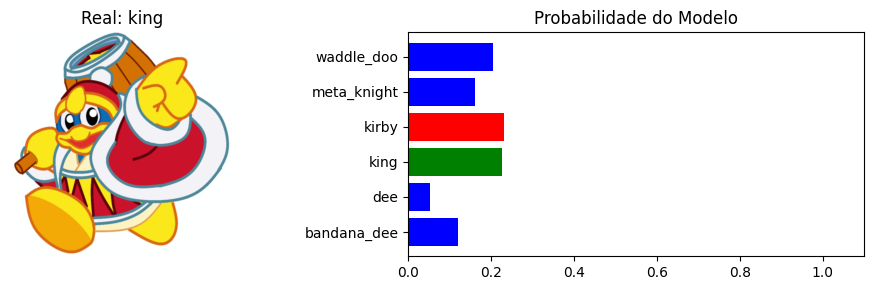

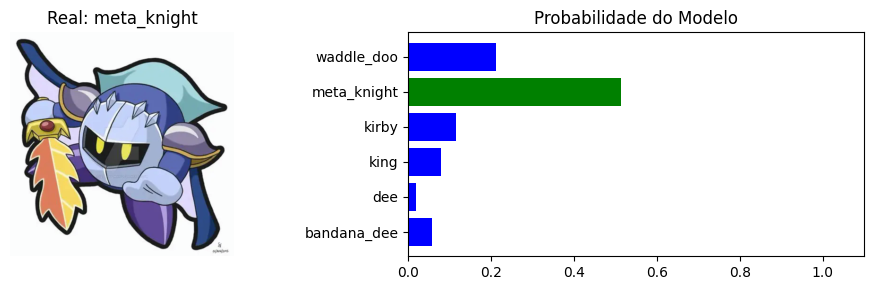

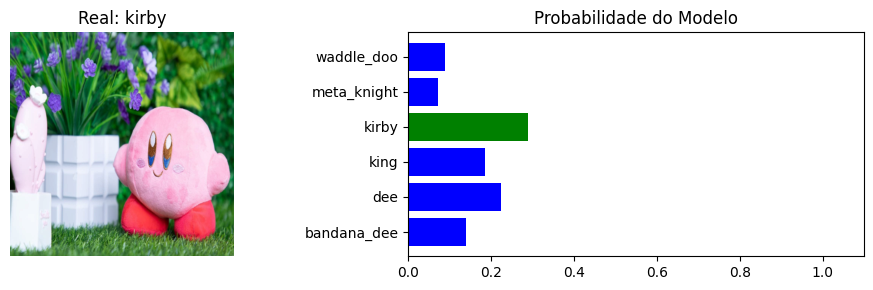

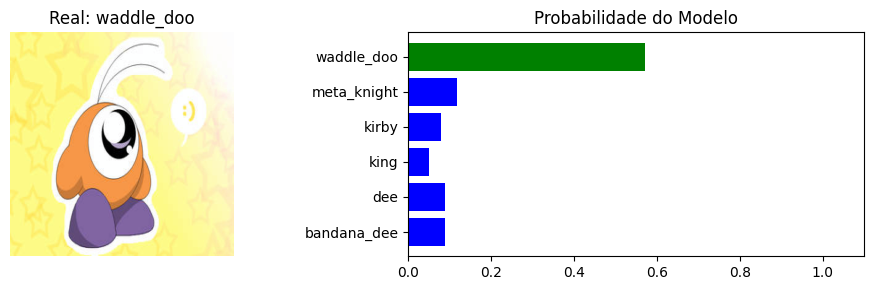

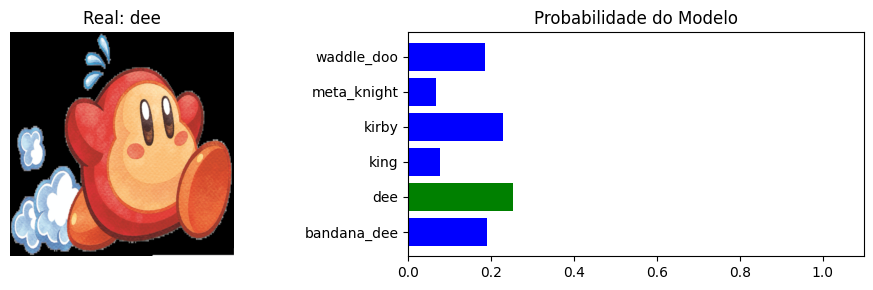

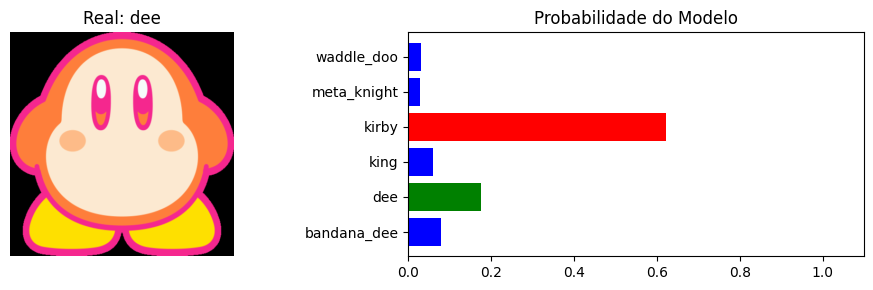

In [124]:
# --- VISUALIZAÇÃO DE INCERTEZA ---
print("\n -- VISUALIZAÇÃO DE INCERTEZA -- ")
visualize_uncertainty(final_model, test_dict, num_images=12)